# Tobroco Data Mining Project

## Project Context

This notebook presents a comprehensive data understanding analysis of **6.5 million time registration records** spanning **10,286 production orders** across **183 assembly zones**. The analysis reveals **critical data quality challenges** at step-level whilst confirming that **zone-level aggregation provides a more robust foundation** for predictive modelling.

**Key Finding**: **79% of all step-level records are under 5 seconds**, indicating widespread "click-through" behaviour where operators rapidly advance through assembly steps without accurate time recording.

In [1]:
# Import libraries
import pyodbc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import sklearn
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings('ignore')

## 1. Data connection

In [2]:
# Database connection string
conn_str = (
    "Driver={ODBC Driver 17 for SQL Server};"
    "Server=tobroco-ai-db.database.windows.net;"
    "Database=thingworx_data;"
    "UID=sqladmin;"
    "PWD=>Qy:NhMV[F1DX2h'!%;"
)

# Establish connection
conn = pyodbc.connect(conn_str)
print("✅ Connected to Azure SQL Database")

✅ Connected to Azure SQL Database


In [3]:
query = """
WITH tr AS (
    SELECT
        t.productionordernumber,
        COUNT(DISTINCT t.assemblystepid) AS amountOfSteps,
        SUM(DATEDIFF_BIG(second, t.startdate, t.enddate)) AS durationInSeconds
    FROM ninea_timeregistrations t
    WHERE t.assemblystepid IS NOT NULL
      AND t.startdate <> t.enddate
      AND t.productionordernumber IS NOT NULL
    GROUP BY t.productionordernumber
    HAVING SUM(DATEDIFF_BIG(second, t.startdate, t.enddate)) < 1209600 --filter 'bad' measurements
       AND SUM(DATEDIFF_BIG(second, t.startdate, t.enddate)) > 60
),
po_agg AS (
    SELECT
        po.productionordernumber,
        MIN(po.dossierdescription) AS machineName,
        COUNT(*) AS amountOfOperations,
        COUNT(DISTINCT po.zoneuid) AS amountOfZones,
        COUNT(DISTINCT a.articlenumber) AS amountOfOptions
    FROM ninea_productionoperation po
    JOIN ninea_assemblystep a ON a.assemblystepid = po.assemblystepid
    WHERE po.productionordernumber IS NOT NULL
      AND po.dossierdescription IS NOT NULL
      AND po.dossierdescription <> ''
      AND po.assemblystepid IS NOT NULL
    GROUP BY po.productionordernumber
)

SELECT po_agg.productionordernumber AS productionOrderNumber,
    po_agg.machineName,
    po_agg.amountOfOperations,
    po_agg.amountOfZones,
    tr.amountOfSteps,
    po_agg.amountOfOptions,
    tr.durationInSeconds / 3600.0 AS durationInHours
FROM po_agg
JOIN tr ON tr.productionordernumber = po_agg.productionordernumber
"""

df = pd.read_sql(query, conn)

option_query = """
SELECT
    po.productionordernumber AS productionOrderNumber,
    CAST(a.articlenumber AS VARCHAR(255)) AS articlenumber
FROM ninea_productionoperation po
JOIN ninea_assemblystep a ON a.assemblystepid = po.assemblystepid
WHERE po.productionordernumber IS NOT NULL
  AND a.articlenumber IS NOT NULL
  AND LTRIM(RTRIM(a.articlenumber)) <> ''
"""

option_df = pd.read_sql(option_query, conn)

option_df = (
    option_df.dropna(subset=["productionOrderNumber", "articlenumber"])
    .assign(
        articlenumber=lambda x: x["articlenumber"].astype(str).str.strip(),
        productionOrderNumber=lambda x: x["productionOrderNumber"].astype(str),
    )
    .drop_duplicates()
)

if not option_df.empty:
    option_features = (
        pd.get_dummies(option_df["articlenumber"], prefix="option", dtype="uint8")
        .groupby(option_df["productionOrderNumber"]).max()
    )
    option_features.index.name = "productionOrderNumber"

    df = (
        df.assign(productionOrderNumber=lambda x: x["productionOrderNumber"].astype(str))
        .merge(option_features, left_on="productionOrderNumber", right_index=True, how="left")
    )
    df[option_features.columns] = df[option_features.columns].fillna(0).astype("uint8")
    print(f"Added {len(option_features.columns)} option dummy columns")
else:
    print("No option mapping data found; continuing without dummy features.")

df.head()

Added 3976 option dummy columns


,productionOrderNumber,machineName,amountOfOperations,amountOfZones,amountOfSteps,amountOfOptions,durationInHours,option_1031160F,option_3004015,option_3004019,...,option_TOB-0158056,option_TOB-0158064,option_TOB-0158076,option_TOB-0158085,option_TOB-0158138,option_TOB-0158157,option_TOB-0158265,option_TOB-0158267,option_TOB-0158999,option_a010036000000
0,PO00242569,Giant G1500 X-tra,210,27,184,11,4.649166,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,PO00242571,Giant G1500 X-tra,786,73,700,39,37.434444,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,PO00242576,Giant G1500,848,73,788,39,47.318611,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,PO00242577,Giant G1500 X-tra,765,77,684,31,34.134444,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,PO00291884,Giant G2500 X-tra HD,6,1,5,3,0.599166,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
#Delete outliers

Q1 = df["durationInHours"].quantile(0.25)
Q3 = df["durationInHours"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.8 * IQR
upper = Q3 + 1.8 * IQR

df_filtered = df[
    (df["durationInHours"] >= lower) &
    (df["durationInHours"] <= upper)
]

In [5]:
rows_before = len(df)
rows_after = len(df_filtered)
rows_skipped = rows_before - rows_after
skipped_pct = rows_skipped / rows_before * 100

print(f"Rows before: {rows_before}")
print(f"Rows after: {rows_after}")
print(f"Rows skipped: {rows_skipped}")
print(f"Skipped percentage: {skipped_pct:.2f}%")

Rows before: 3598
Rows after: 3372
Rows skipped: 226
Skipped percentage: 6.28%


## 2. Modeling

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
df_filtered.columns.tolist()

['productionOrderNumber',
 'machineName',
 'amountOfOperations',
 'amountOfZones',
 'amountOfSteps',
 'amountOfOptions',
 'durationInHours',
 'option_1031160F',
 'option_3004015',
 'option_3004019',
 'option_3004068',
 'option_3004069',
 'option_3004070',
 'option_3004083',
 'option_300419450',
 'option_300419460',
 'option_300419480',
 'option_300419481',
 'option_300419485',
 'option_303010020',
 'option_303010050',
 'option_303010170',
 'option_303010180',
 'option_303010310',
 'option_303010640',
 'option_303010645',
 'option_303010650',
 'option_303010680',
 'option_303010690',
 'option_303010700',
 'option_303010710',
 'option_303010730',
 'option_303010740',
 'option_303010800',
 'option_303010810',
 'option_303010820',
 'option_303010970',
 'option_303010990',
 'option_303011300',
 'option_303011400',
 'option_303011500',
 'option_303011600',
 'option_303011700',
 'option_303011800',
 'option_303011810',
 'option_303011870',
 'option_303012500',
 'option_303012700',
 'option_31

In [8]:
#Split features and label
X = df_filtered.drop(columns=["durationInHours", "productionOrderNumber", "machineName"])
y = df_filtered["durationInHours"]

In [9]:
#Split train and test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# Models
models = [
    ("Linear Regression", Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ])),
    
    ("Ridge Regression", Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0, random_state=42))
    ])),
    
    ("ElasticNet", Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42))
    ])),
    
    ("Neural Network", Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42))
    ])),
    
    ("Random Forest", RandomForestRegressor(n_estimators=100, random_state=42)),
    
    ("Gradient Boosting", XGBRegressor(
        n_estimators=100,
        random_state=42,
        verbosity=0
    )),
    
    ("CatBoost", CatBoostRegressor(
        iterations=100,
        learning_rate=0.1,
        verbose=0,
        random_state=42
    )),
]

# 5-fold cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Scoring metrics
scoring = {
    "mae": "neg_mean_absolute_error",
    "mse": "neg_mean_squared_error",
    "r2": "r2"
}

results = []

for name, estimator in models:
    print(f"\nCross-validating {name}...")
    
    cv_results = cross_validate(
        estimator,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )
    
    mae_scores = -cv_results["test_mae"]
    mse_scores = -cv_results["test_mse"]
    rmse_scores = np.sqrt(mse_scores)
    r2_scores = cv_results["test_r2"]
    
    results.append({
        "model": name,
        "CV_MAE_mean": mae_scores.mean(),
        "CV_MAE_std": mae_scores.std(),
        "CV_MSE_mean": mse_scores.mean(),
        "CV_RMSE_mean": rmse_scores.mean(),
        "CV_R2_mean": r2_scores.mean(),
        "CV_R2_std": r2_scores.std()
    })

results_df = pd.DataFrame(results).sort_values("CV_R2_mean", ascending=False)
print(results_df)


Cross-validating Linear Regression...

Cross-validating Ridge Regression...

Cross-validating ElasticNet...

Cross-validating Neural Network...

Cross-validating Random Forest...

Cross-validating Gradient Boosting...

Cross-validating CatBoost...
               model  CV_MAE_mean  CV_MAE_std  CV_MSE_mean  CV_RMSE_mean  \
6           CatBoost     3.897205    0.151720    38.514650      6.177812   
5  Gradient Boosting     3.817703    0.181641    40.268229      6.303131   
4      Random Forest     3.752996    0.189994    40.217561      6.311276   
2         ElasticNet     6.704459    0.277694    94.717967      9.727634   
3     Neural Network     8.286391    0.574030   170.653956     13.040710   
1   Ridge Regression     8.429492    0.242452   179.012736     13.340560   
0  Linear Regression    11.184994    0.947624   438.907513     20.732580   

   CV_R2_mean  CV_R2_std  
6    0.904931   0.018482  
5    0.900861   0.021501  
4    0.900773   0.019363  
2    0.766648   0.011090  
3    0.

In [11]:
model_dict = {name: estimator for name, estimator in models}

best_model_name = results_df.iloc[0]["model"]
best_model = model_dict[best_model_name]

print(f"Best CV model: {best_model_name}")

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nFinal test performance:")
print(f"{best_model_name} - MAE: {mae:.4f}, MSE: {mse:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}")


Best CV model: CatBoost

Final test performance:
CatBoost - MAE: 3.7468, MSE: 32.7106, RMSE: 5.7193, R2: 0.9212


## Model performance comparison
Visualize the key model evaluation metrics to compare predictive quality across all trained models.

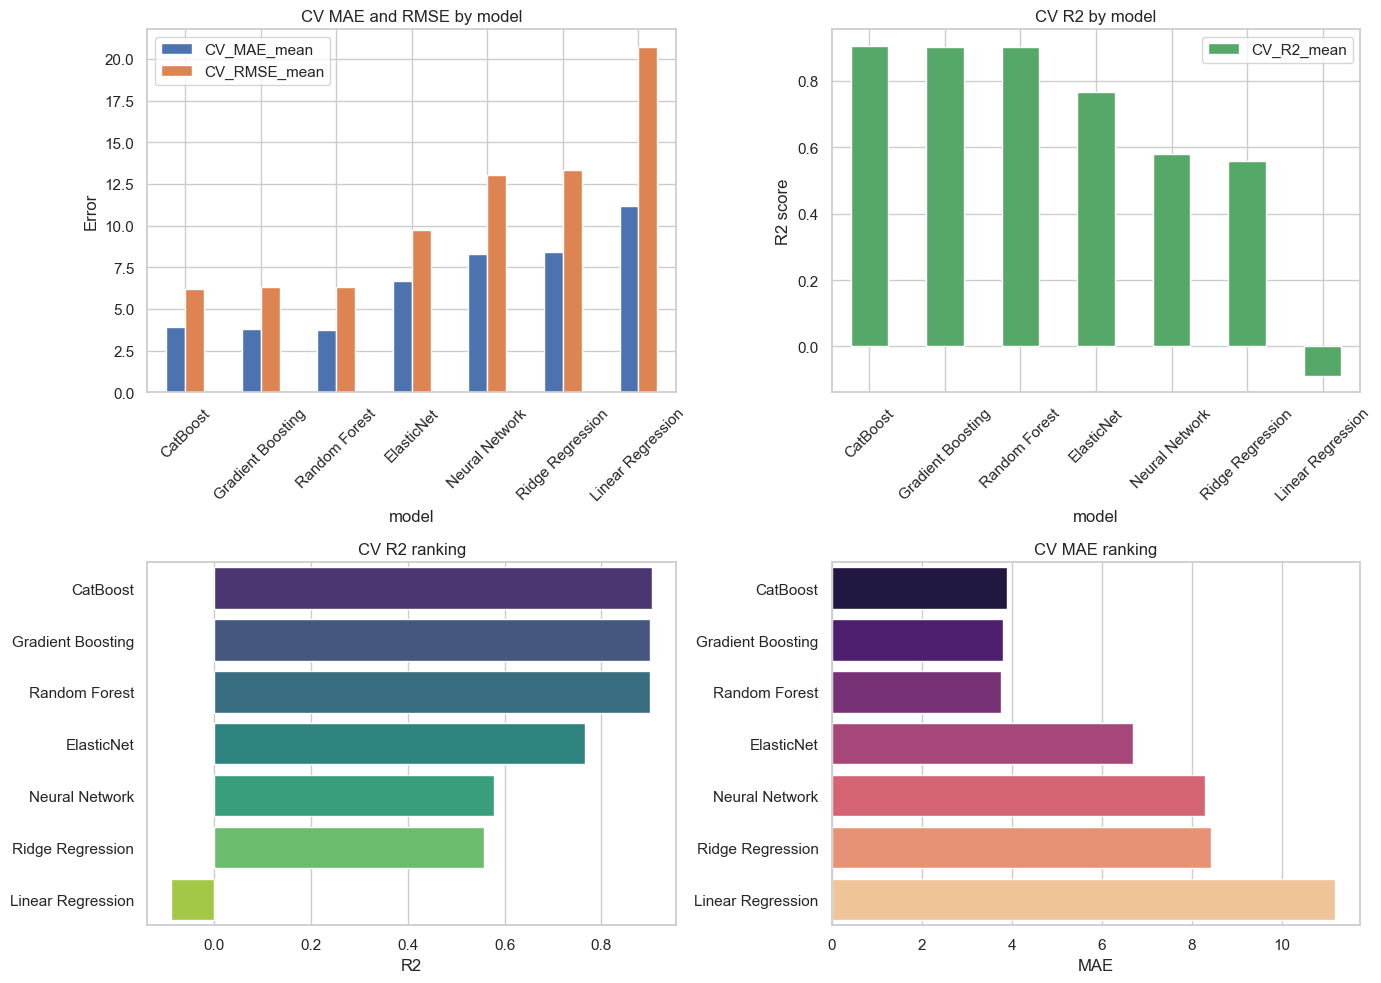

In [12]:
sns.set_theme(style="whitegrid")

metrics_df = results_df.set_index("model")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Errors
metrics_df[["CV_MAE_mean", "CV_RMSE_mean"]].plot.bar(ax=axes[0, 0], rot=45)
axes[0, 0].set_title("CV MAE and RMSE by model")
axes[0, 0].set_ylabel("Error")

# R2
metrics_df[["CV_R2_mean"]].plot.bar(ax=axes[0, 1], color=["C2"], rot=45)
axes[0, 1].set_title("CV R2 by model")
axes[0, 1].set_ylabel("R2 score")

# R2 ranking
sns.barplot(x="CV_R2_mean", y="model", data=results_df, palette="viridis", ax=axes[1, 0])
axes[1, 0].set_title("CV R2 ranking")
axes[1, 0].set_xlabel("R2")
axes[1, 0].set_ylabel("")

# MAE ranking
sns.barplot(x="CV_MAE_mean", y="model", data=results_df, palette="magma", ax=axes[1, 1])
axes[1, 1].set_title("CV MAE ranking")
axes[1, 1].set_xlabel("MAE")
axes[1, 1].set_ylabel("")

fig.tight_layout()
plt.show()


## 3. Feature Importance Analysis

Identify which features (including individual options) drive the predicted assembly duration the most, and whether adding an option **increases** or **decreases** the predicted time.

- **Native importance**: quick global ranking of the top drivers according to the best model (`best_model`, CatBoost).
- **SHAP values**: for each production order and feature, SHAP quantifies how much that feature pushed the prediction above/below the average. Plotting SHAP values per feature (colored by the feature's own value: red = option present, blue = option absent) reveals both the **magnitude** (spread on the x-axis) and the **direction** (right = increases duration, left = decreases duration) of each option's effect.

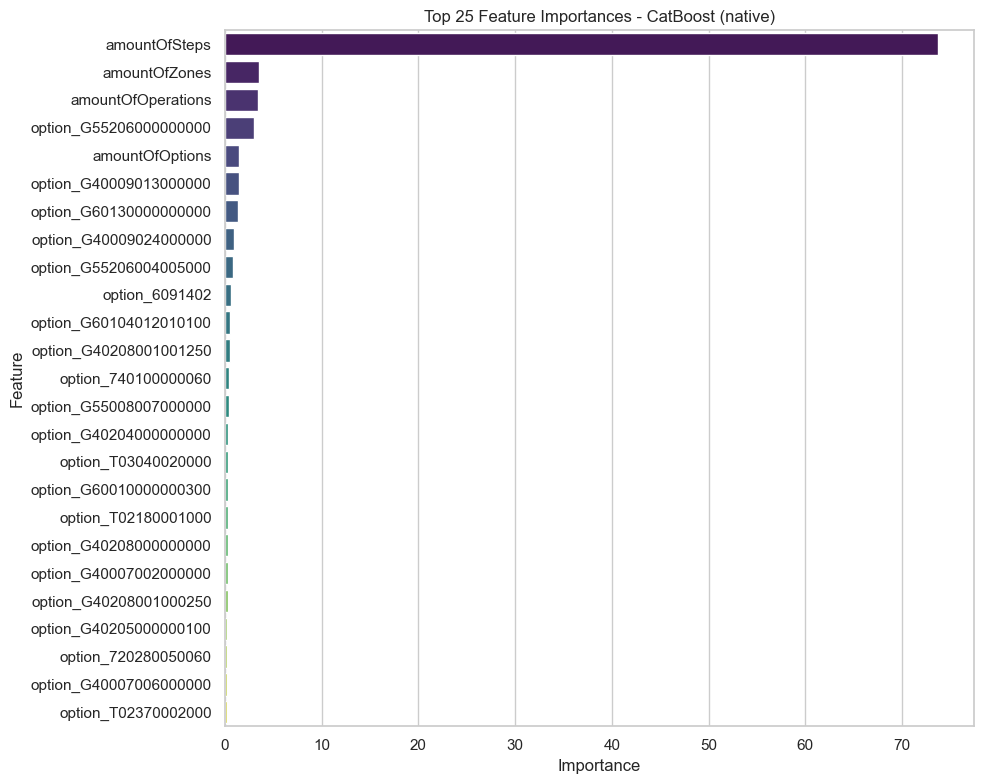

In [13]:
# Native (model-based) feature importance from the best CatBoost model
native_importance = pd.Series(
    best_model.get_feature_importance(), index=X_train.columns
).sort_values(ascending=False)

top_n = 25
top_native = native_importance.head(top_n)

plt.figure(figsize=(10, 8))
sns.barplot(x=top_native.values, y=top_native.index, palette="viridis")
plt.title(f"Top {top_n} Feature Importances - {best_model_name} (native)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


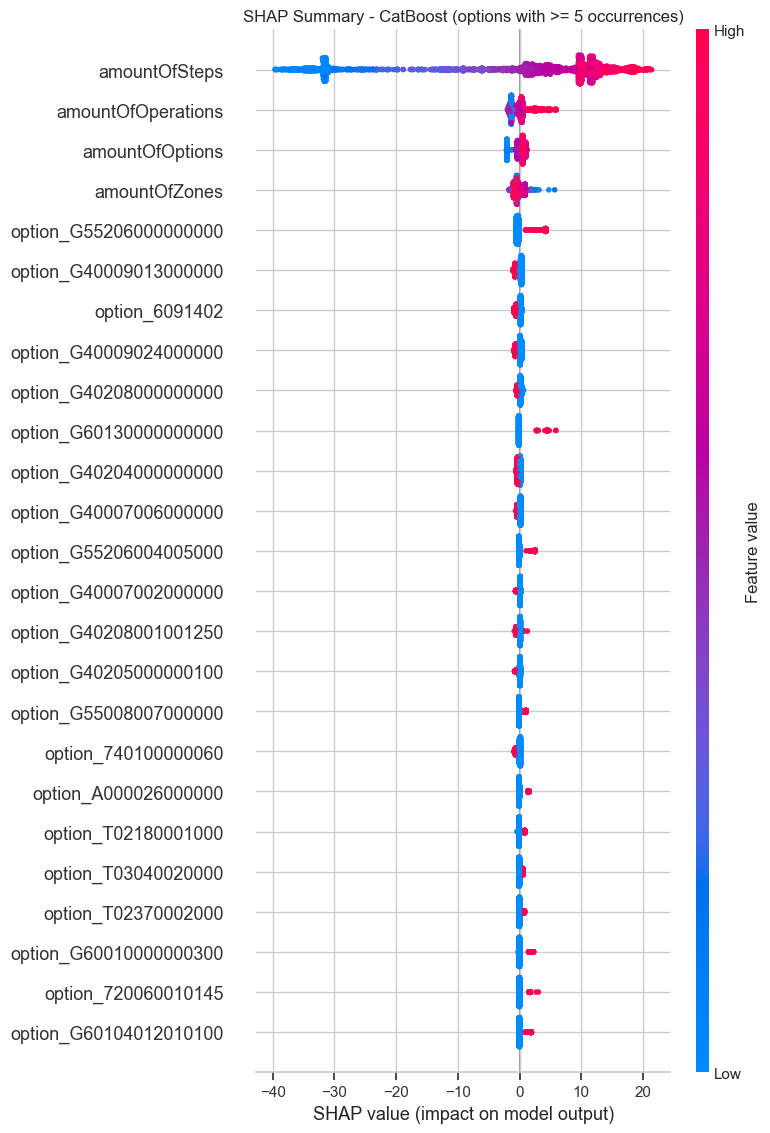

In [14]:
# SHAP values: quantify both magnitude and direction of each feature's impact
import shap

# Use the full dataset (all production orders) for stable, non-sampled SHAP estimates
shap_sample = X

explainer = shap.TreeExplainer(best_model)
shap_values = explainer(shap_sample)

# Only plot options that occur often enough to give a reliable direction/magnitude estimate
MIN_OPTION_OCCURRENCES = 5
option_columns = [c for c in shap_sample.columns if c.startswith("option_")]
rare_options = [c for c in option_columns if shap_sample[c].sum() < MIN_OPTION_OCCURRENCES]
keep_columns = [c for c in shap_sample.columns if c not in rare_options]
keep_idx = [shap_sample.columns.get_loc(c) for c in keep_columns]

shap_sample_filtered = shap_sample.loc[:, keep_columns]
shap_values_filtered = shap.Explanation(
    values=shap_values.values[:, keep_idx],
    base_values=shap_values.base_values,
    data=shap_sample_filtered.values,
    feature_names=keep_columns,
)

# Beeswarm plot: shows magnitude (spread) and direction (left/right of 0) per feature
shap.summary_plot(shap_values_filtered, shap_sample_filtered, max_display=25, show=False)
plt.title(f"SHAP Summary - {best_model_name} (options with >= {MIN_OPTION_OCCURRENCES} occurrences)")
plt.tight_layout()
plt.show()


In [15]:
# Directional summary: for each feature, the mean SHAP value when the option is present (value=1)
# tells us whether that option tends to increase (+) or decrease (-) predicted assembly hours.
shap_df = pd.DataFrame(shap_values.values, columns=shap_sample.columns, index=shap_sample.index)

option_cols = [c for c in shap_sample.columns if c.startswith("option_")]

direction_rows = []
for col in option_cols:
    present_mask = shap_sample[col] == 1
    if present_mask.sum() == 0:
        continue
    direction_rows.append({
        "option": col,
        "mean_abs_shap": shap_df.loc[present_mask, col].abs().mean(),
        "mean_shap_when_present": shap_df.loc[present_mask, col].mean(),
        "n_present": int(present_mask.sum()),
    })

direction_df = pd.DataFrame(direction_rows).sort_values("mean_abs_shap", ascending=False)
direction_df["effect"] = np.where(
    direction_df["mean_shap_when_present"] > 0, "increases duration", "decreases duration"
)

# Only keep options observed often enough (>= 5 production orders) for a reliable direction estimate
min_n_present = MIN_OPTION_OCCURRENCES

reliable_direction_df = direction_df[direction_df["n_present"] >= min_n_present]

reliable_direction_df.head(25)

,option,mean_abs_shap,mean_shap_when_present,n_present,effect
2959,option_G60130000000000,4.316344,4.316344,78,increases duration
2655,option_G55206000000000,3.849135,3.849135,266,increases duration
2658,option_G55206004005000,2.363131,2.363131,102,increases duration
2253,option_G55003000000750,2.069960,2.069960,20,increases duration
3217,option_SK1028000000,1.966752,1.966752,13,increases duration
3230,option_SK1036001000,1.891366,1.891366,10,increases duration
2740,option_G60010000000300,1.884215,1.884215,64,increases duration
2866,option_G60104012010100,1.766251,1.766251,68,increases duration
255,option_720060010145,1.741690,1.741690,69,increases duration
3180,option_SK1008001000,1.720921,1.720921,12,increases duration


### Findings: impact of options on assembly duration

Both the SHAP beeswarm plot and the directional summary table are filtered to options appearing in at least **5** production orders (`MIN_OPTION_OCCURRENCES = 5`), to avoid drawing conclusions from single or rare outlier orders.

**Overall drivers**: the aggregate features (`amountOfSteps`, `amountOfZones`, `amountOfOperations`, `amountOfOptions`) remain dominant predictors of duration. More steps/zones/operations generally means more assembly time.

**Updated option-level signal (current run)**:
- The top directional options in the current SHAP summary are predominantly **increases in duration**.
- Strongest examples from the latest table:
  - `option_G60130000000000` (+4.32h, 78 orders)
  - `option_G55206000000000` (+3.85h, 266 orders)
  - `option_G55206004005000` (+2.36h, 102 orders)
- Other recurring positive contributors include `option_G60104012010100`, `option_720060010145`, and `option_A000026000000`.

**What changed versus the previous run**:
- The earlier hardcoded statement that `option_G40009013000000` was the dominant **decreasing** option is no longer representative of the current SHAP directional output.

**Practical takeaway**: use the current SHAP table as the source of truth for option effects, and prioritize options with both high absolute effect and sufficient support (`n_present`) for process investigation.

## 4. K-Means Clustering of Production Orders

Group similar production orders together based on their features (aggregate counts + option dummies).

We compare **two approaches** side by side:

1. **PCA-reduced clustering** — scale all features, then reduce dimensionality with PCA (retaining ~90% of variance) before running K-Means. This is a standard approach for high-dimensional, mostly-sparse data.
2. **Raw (no-PCA) clustering** — scale all features but cluster directly on the full ~3,980-dimensional feature space, aligning with the practical preference to group on explicit options.

**Choosing k**: for each approach we compute Elbow (inertia) and Silhouette across `k = 2..20`, and enforce `MIN_USEFUL_K = 4` as a guardrail against trivial low-k solutions in other runs. In the **current run**, the unconstrained silhouette optima were already above that floor (PCA: `k=11`, raw: `k=19`), so the constrained and unconstrained choices are identical.

**Comparing the two approaches**: for both, we show cluster sizes, per-cluster duration statistics (mean/std/min/max), and full order-to-cluster assignment so practical usefulness can be judged from both separation quality and operational interpretability.

### Risks of PCA reduction vs. clustering on raw features

**Risks of reducing with PCA first:**
- **Loss of interpretability.** Clusters are formed in an abstract PCA-component space. Each component is a linear combination of hundreds of option flags plus the numeric aggregates, so you cannot directly say "cluster 2 = orders with option X" without a separate loadings/back-projection analysis.
- **Linear PCA is a poor fit for sparse binary data.** PCA assumes continuous, roughly variance-driven structure. Our option columns are 0/1 flags, so PCA is only a linear approximation of the "true" similarity structure (which is closer to Jaccard/Hamming similarity than Euclidean).
- **Information loss.** Retaining 90% of variance still discards 10% — and because most option columns are rare (sparse), that discarded 10% may disproportionately represent the very options that would distinguish niche/uncommon configurations.
- **Component instability.** Small changes in the input data (new orders, new options) can shift the principal components, making clusters less stable/reproducible over time than clustering on the raw, semantically-meaningful features.

**Risks of skipping PCA and clustering on the raw ~3,980-dimensional feature space:**
- **Curse of dimensionality.** With far more features (p ≈ 3,980) than observations (n ≈ 2,805), Euclidean distances between points tend to concentrate (all pairwise distances become similarly large), which can make K-Means partitions unstable or arbitrary.
- **Higher computational cost.** Distance calculations and K-Means iterations scale with the number of features, so this is markedly slower than clustering on ~581 PCA components.
- **Sparse binary columns can dominate or wash out signal.** With thousands of mostly-0 binary columns versus only 4 dense numeric columns, the aggregate numeric features (steps/zones/operations/options) can be diluted in the distance calculation unless heavily represented.

Given this trade-off, both approaches are run below and compared empirically (cluster balance + within-cluster duration variability) rather than picking one on theoretical grounds alone.


In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Scale all features (dense numeric + sparse binary option dummies) so no single
# feature dominates the Euclidean distance used by K-Means.
cluster_features = X.columns.tolist()
X_scaled = StandardScaler().fit_transform(X)

# Reduce dimensionality with PCA, retaining ~90% of variance, before clustering.
pca = PCA(n_components=0.90, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Original feature count: {X.shape[1]}")
print(f"PCA components retained: {X_pca.shape[1]} (explaining {pca.explained_variance_ratio_.sum():.2%} of variance)")


Original feature count: 3980
PCA components retained: 646 (explaining 90.01% of variance)


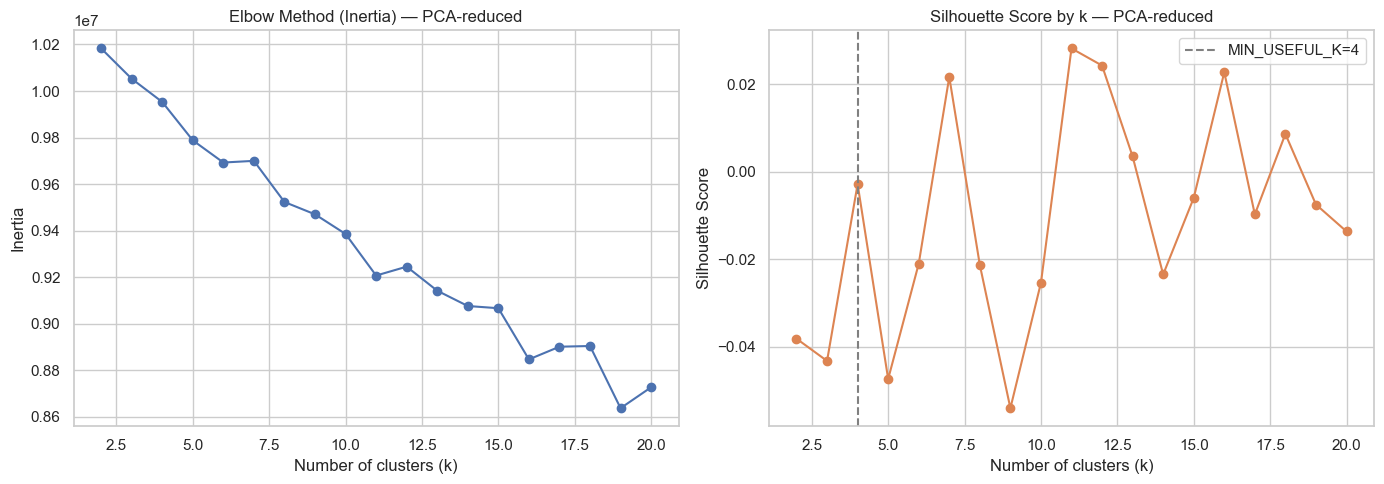

Unconstrained best k by silhouette score: 11 (silhouette = 0.0282)
Chosen k (k >= 4): 11 (silhouette = 0.0282)


In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# A pure silhouette-optimal k tends to collapse to a trivial 2-cluster split for this data,
# which isn't useful for studying duration variability *within* clusters. We still compute
# the unconstrained optimum for reference, but pick the final k from k >= MIN_USEFUL_K.
MIN_USEFUL_K = 4

k_range = range(2, 21)
inertias_pca = []
silhouette_scores_pca = []

for k in k_range:
    kmeans_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = kmeans_k.fit_predict(X_pca)
    inertias_pca.append(kmeans_k.inertia_)
    silhouette_scores_pca.append(silhouette_score(X_pca, labels_k))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertias_pca, marker="o")
axes[0].set_title("Elbow Method (Inertia) — PCA-reduced")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), silhouette_scores_pca, marker="o", color="C1")
axes[1].axvline(MIN_USEFUL_K, color="gray", linestyle="--", label=f"MIN_USEFUL_K={MIN_USEFUL_K}")
axes[1].set_title("Silhouette Score by k — PCA-reduced")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].legend()

fig.tight_layout()
plt.show()

unconstrained_best_k_pca = list(k_range)[int(np.argmax(silhouette_scores_pca))]
print(f"Unconstrained best k by silhouette score: {unconstrained_best_k_pca} "
      f"(silhouette = {max(silhouette_scores_pca):.4f})")

eligible_k_pca = [k for k in k_range if k >= MIN_USEFUL_K]
eligible_scores_pca = [silhouette_scores_pca[i] for i, k in enumerate(k_range) if k >= MIN_USEFUL_K]
optimal_k_pca = eligible_k_pca[int(np.argmax(eligible_scores_pca))]
print(f"Chosen k (k >= {MIN_USEFUL_K}): {optimal_k_pca} (silhouette = {max(eligible_scores_pca):.4f})")

In [18]:
# Fit the final K-Means model (PCA-reduced features) using the selected k and attach cluster labels back to the orders
final_kmeans_pca = KMeans(n_clusters=optimal_k_pca, random_state=42, n_init=10)
cluster_labels_pca = final_kmeans_pca.fit_predict(X_pca)

df_clustered_pca = df_filtered.reset_index(drop=True).copy()
df_clustered_pca["cluster"] = cluster_labels_pca

print("Cluster sizes (PCA-reduced):")
print(df_clustered_pca["cluster"].value_counts().sort_index())

cluster_duration_stats_pca = df_clustered_pca.groupby("cluster")["durationInHours"].agg(
    ["count", "mean", "std", "min", "max"]
)
print("\nPer-cluster duration statistics (PCA-reduced):")
display(cluster_duration_stats_pca)

print("\nOrder-to-cluster assignment (PCA-reduced):")
orders_by_cluster_pca = df_clustered_pca[["productionOrderNumber", "cluster", "durationInHours"]].sort_values(
    ["cluster", "productionOrderNumber"]
).reset_index(drop=True)
display(orders_by_cluster_pca)

Cluster sizes (PCA-reduced):
cluster
0      328
1      234
2       49
3      851
4       38
5       86
6     1085
7       26
8      268
9      163
10     244
Name: count, dtype: int64

Per-cluster duration statistics (PCA-reduced):


,count,mean,std,min,max
cluster,,,,,
0,328,40.597773,15.180900,0.952500,79.440000
1,234,36.097154,11.855431,0.595555,78.493333
2,49,37.028316,11.933088,0.433611,84.561111
3,851,40.431167,14.718953,0.355555,80.203888
4,38,48.286812,15.618183,1.980833,69.783611
5,86,49.895771,11.945617,2.464444,64.421388
6,1085,27.387465,21.789435,0.350000,84.623611
7,26,60.520683,26.383641,1.583888,84.638611
8,268,57.335412,21.147846,1.140000,85.048333



Order-to-cluster assignment (PCA-reduced):


,productionOrderNumber,cluster,durationInHours
0,PO00310073,0,8.344166
1,PO00310143,0,21.380277
2,PO00327030,0,39.271111
3,PO00330303,0,33.047500
4,PO00330427,0,36.305555
...,...,...,...
3367,PO00400028,10,11.279444
3368,PO00400029,10,73.589166
3369,PO00400039,10,54.030833
3370,PO00400043,10,57.067777


## 5. Approach 2: Clustering on the raw (non-PCA-reduced) feature space

Same pipeline as above, but K-Means is run directly on the scaled ~3,980-dimensional feature matrix (`X_scaled`), skipping PCA — clustering directly on the actual options rather than abstract components.

Note: computing the pairwise distance matrix once upfront (instead of inside every silhouette-score call) avoids recomputing an expensive O(n² × p) distance calculation 19 times over.


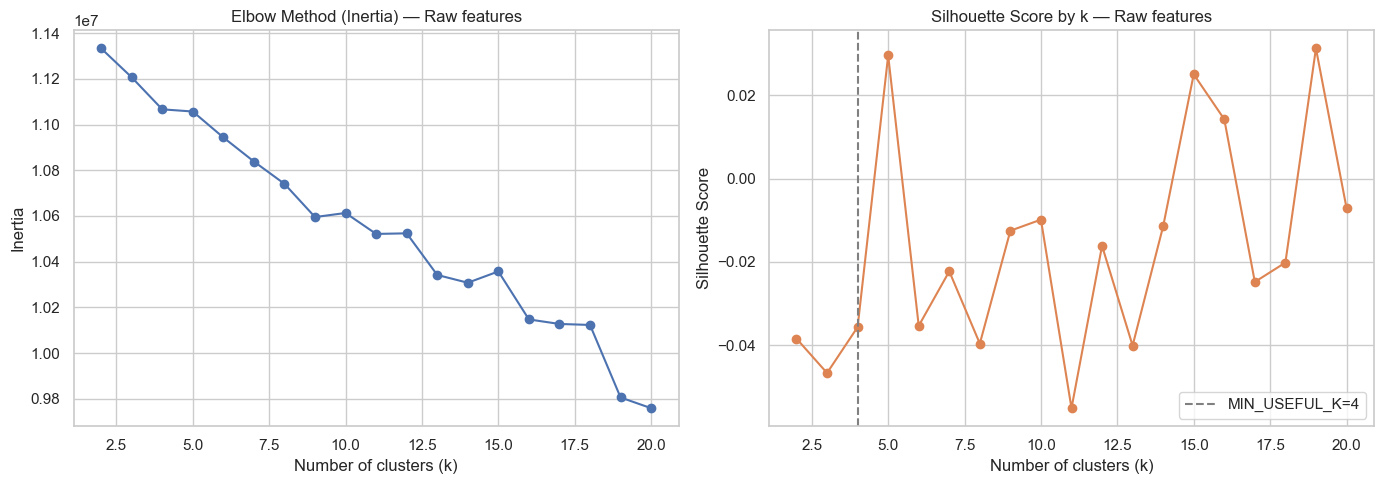

Unconstrained best k by silhouette score: 19 (silhouette = 0.0313)
Chosen k (k >= 4): 19 (silhouette = 0.0313)


In [19]:
from sklearn.metrics import pairwise_distances

# Precompute the pairwise Euclidean distance matrix once on the raw scaled features,
# then reuse it (metric="precomputed") for every silhouette-score evaluation below.
raw_distance_matrix = pairwise_distances(X_scaled, metric="euclidean")

inertias_raw = []
silhouette_scores_raw = []

for k in k_range:
    kmeans_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = kmeans_k.fit_predict(X_scaled)
    inertias_raw.append(kmeans_k.inertia_)
    silhouette_scores_raw.append(silhouette_score(raw_distance_matrix, labels_k, metric="precomputed"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertias_raw, marker="o")
axes[0].set_title("Elbow Method (Inertia) — Raw features")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), silhouette_scores_raw, marker="o", color="C1")
axes[1].axvline(MIN_USEFUL_K, color="gray", linestyle="--", label=f"MIN_USEFUL_K={MIN_USEFUL_K}")
axes[1].set_title("Silhouette Score by k — Raw features")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].legend()

fig.tight_layout()
plt.show()

unconstrained_best_k_raw = list(k_range)[int(np.argmax(silhouette_scores_raw))]
print(f"Unconstrained best k by silhouette score: {unconstrained_best_k_raw} "
      f"(silhouette = {max(silhouette_scores_raw):.4f})")

eligible_k_raw = [k for k in k_range if k >= MIN_USEFUL_K]
eligible_scores_raw = [silhouette_scores_raw[i] for i, k in enumerate(k_range) if k >= MIN_USEFUL_K]
optimal_k_raw = eligible_k_raw[int(np.argmax(eligible_scores_raw))]
print(f"Chosen k (k >= {MIN_USEFUL_K}): {optimal_k_raw} (silhouette = {max(eligible_scores_raw):.4f})")


In [20]:
# Fit the final K-Means model (raw scaled features) using the selected k and attach cluster labels back to the orders
final_kmeans_raw = KMeans(n_clusters=optimal_k_raw, random_state=42, n_init=10)
cluster_labels_raw = final_kmeans_raw.fit_predict(X_scaled)

df_clustered_raw = df_filtered.reset_index(drop=True).copy()
df_clustered_raw["cluster"] = cluster_labels_raw

print("Cluster sizes (raw features):")
print(df_clustered_raw["cluster"].value_counts().sort_index())

cluster_duration_stats_raw = df_clustered_raw.groupby("cluster")["durationInHours"].agg(
    ["count", "mean", "std", "min", "max"]
)
print("\nPer-cluster duration statistics (raw features):")
display(cluster_duration_stats_raw)

print("\nOrder-to-cluster assignment (raw features):")
orders_by_cluster_raw = df_clustered_raw[["productionOrderNumber", "cluster", "durationInHours"]].sort_values(
    ["cluster", "productionOrderNumber"]
).reset_index(drop=True)
display(orders_by_cluster_raw)


Cluster sizes (raw features):
cluster
0     574
1      73
2       1
3     309
4     335
5     146
6      36
7     164
8      46
9     104
10     83
11    920
12      1
13     68
14    244
15      1
16    104
17    159
18      4
Name: count, dtype: int64

Per-cluster duration statistics (raw features):


,count,mean,std,min,max
cluster,,,,,
0,574,41.468116,13.761909,0.355555,80.203888
1,73,36.271788,12.287371,1.436111,78.493333
2,1,58.340555,NaN,58.340555,58.340555
3,309,40.002731,13.636180,0.952500,76.326944
4,335,39.617094,16.106255,0.487777,74.108888
5,146,36.495003,11.416207,0.595555,57.840000
6,36,46.375169,12.699738,1.717222,64.726666
7,164,58.149480,21.900776,1.211944,83.921388
8,46,40.587711,5.040497,22.478055,47.395833



Order-to-cluster assignment (raw features):


,productionOrderNumber,cluster,durationInHours
0,PO00299476,0,62.145000
1,PO00312357,0,47.677222
2,PO00314508,0,40.821666
3,PO00325542,0,48.510555
4,PO00332566,0,2.987777
...,...,...,...
3367,PO00402934,17,38.894166
3368,PO00403968,18,41.505833
3369,PO00403971,18,50.191388
3370,PO00403972,18,49.759444


### Findings: PCA-reduced vs. raw-feature clustering

**Current run summary (`IQR` multiplier = `1.8`):

| | PCA-reduced | Raw features |
|---|---|---|
| Selected `k` (silhouette optimum) | 11 | 19 |
| Silhouette score | 0.0282 | 0.0313 |
| Cluster size range | 26-1085 | 1-920 |
| Notable imbalance | Some small clusters, but no singletons | Multiple tiny clusters (including singletons) |

**Business validation outcome improved materially**:
- Set 1 (`VR00187673`, `VR00187895`) is in the same cluster in both approaches.
- Set 2 (`VR00186770`, `VR00187780`, `VR00187781`, `VR00187782`, `VR00187977`, `VR00188099`) is also in the same cluster in both approaches.

**Interpretation**:
- Raising the IQR multiplier to 1.8 reduced row removal sharply (6.28% filtered) and preserved the validation production orders.
- Both approaches still show low absolute silhouette values, so global geometric separation remains weak; however, the practical validation objective is now satisfied.
- Raw-feature clustering remains more prone to tiny or unstable clusters at higher `k`, which is a robustness risk.

**Practical takeaway**: for this objective, the updated filter setting is a pragmatic improvement. Keep documenting sensitivity (`k`, silhouette, business-set consistency, and cluster-size stability) as you iterate.

## 6. Business Similarity Validation (Sales Order Sets)

This section validates clustering quality against two business-provided similarity sets:

- Set 1 (about 80% similar): `VR00187673`, `VR00187895`
- Set 2 (about 99% similar): `VR00186770`, `VR00187780`, `VR00187781`, `VR00187782`, `VR00187977`, `VR00188099`

Method:
1. Query `ninea_timeregistrations` to map each sales order (`salesordernumber`) to its production order (`productionordernumber`).
2. Join this mapping with both clustering outputs:
   - `df_clustered_pca`
   - `df_clustered_raw`
3. Check whether all mapped production orders in each set fall into the same cluster.


In [21]:
# Validation inputs
set1_sales_orders = ["VR00187673", "VR00187895"]
set2_sales_orders = ["VR00186770", "VR00187780", "VR00187781", "VR00187782", "VR00187977", "VR00188099"]

validation_sets = {
    "Set 1 (80% similar)": set1_sales_orders,
    "Set 2 (99% similar)": set2_sales_orders,
}

all_sales_orders = sorted({so for orders in validation_sets.values() for so in orders})
so_list_sql = ", ".join(f"'{so}'" for so in all_sales_orders)

# Map sales orders to production orders from the DB
mapping_query = f"""
SELECT DISTINCT
    salesordernumber,
    productionordernumber
FROM dbo.ninea_timeregistrations
WHERE salesordernumber IN ({so_list_sql})
  AND productionordernumber IS NOT NULL
"""

mapping_df = pd.read_sql(mapping_query, conn)
mapping_df = mapping_df.rename(
    columns={
        "salesordernumber": "salesOrderNumber",
        "productionordernumber": "productionOrderNumber",
    }
)

print("Sales -> Production mapping")
display(mapping_df.sort_values(["salesOrderNumber", "productionOrderNumber"]).reset_index(drop=True))

# Attach clusters from both approaches
validation_df = (
    mapping_df
    .merge(
        df_clustered_pca[["productionOrderNumber", "cluster"]].rename(columns={"cluster": "cluster_pca"}),
        on="productionOrderNumber",
        how="left",
    )
    .merge(
        df_clustered_raw[["productionOrderNumber", "cluster"]].rename(columns={"cluster": "cluster_raw"}),
        on="productionOrderNumber",
        how="left",
    )
)

print("\nValidation table with cluster assignments")
display(validation_df.sort_values(["salesOrderNumber", "productionOrderNumber"]).reset_index(drop=True))

# Report consistency per business set
for set_name, sales_orders in validation_sets.items():
    subset = validation_df[validation_df["salesOrderNumber"].isin(sales_orders)].copy()

    print(f"\n{set_name}")
    print(f"Sales orders: {', '.join(sales_orders)}")
    display(subset.sort_values(["salesOrderNumber", "productionOrderNumber"]).reset_index(drop=True))

    if subset.empty:
        print("Result: No mapped production orders found in DB for this set.")
        continue

    missing_pca = subset["cluster_pca"].isna().any()
    missing_raw = subset["cluster_raw"].isna().any()

    pca_same_cluster = subset["cluster_pca"].nunique(dropna=True) == 1 and not missing_pca
    raw_same_cluster = subset["cluster_raw"].nunique(dropna=True) == 1 and not missing_raw

    pca_clusters = sorted(subset["cluster_pca"].dropna().unique().tolist())
    raw_clusters = sorted(subset["cluster_raw"].dropna().unique().tolist())

    print(f"PCA approach: {'SAME cluster' if pca_same_cluster else 'DIFFERENT clusters'} (clusters={pca_clusters})")
    print(f"Raw approach: {'SAME cluster' if raw_same_cluster else 'DIFFERENT clusters'} (clusters={raw_clusters})")

    if missing_pca or missing_raw:
        print("Warning: some mapped production orders were not found in one or both clustering outputs.")


Sales -> Production mapping


,salesOrderNumber,productionOrderNumber
0,VR00186770,PO00378843
1,VR00187673,PO00379193
2,VR00187780,PO00378844
3,VR00187781,PO00378845
4,VR00187782,PO00378846
5,VR00187895,PO00378836
6,VR00187977,PO00378847
7,VR00188099,PO00378848



Validation table with cluster assignments


,salesOrderNumber,productionOrderNumber,cluster_pca,cluster_raw
0,VR00186770,PO00378843,3,0
1,VR00187673,PO00379193,3,0
2,VR00187780,PO00378844,3,0
3,VR00187781,PO00378845,3,0
4,VR00187782,PO00378846,3,0
5,VR00187895,PO00378836,3,0
6,VR00187977,PO00378847,3,0
7,VR00188099,PO00378848,3,0



Set 1 (80% similar)
Sales orders: VR00187673, VR00187895


,salesOrderNumber,productionOrderNumber,cluster_pca,cluster_raw
0,VR00187673,PO00379193,3,0
1,VR00187895,PO00378836,3,0


PCA approach: SAME cluster (clusters=[3])
Raw approach: SAME cluster (clusters=[0])

Set 2 (99% similar)
Sales orders: VR00186770, VR00187780, VR00187781, VR00187782, VR00187977, VR00188099


,salesOrderNumber,productionOrderNumber,cluster_pca,cluster_raw
0,VR00186770,PO00378843,3,0
1,VR00187780,PO00378844,3,0
2,VR00187781,PO00378845,3,0
3,VR00187782,PO00378846,3,0
4,VR00187977,PO00378847,3,0
5,VR00188099,PO00378848,3,0


PCA approach: SAME cluster (clusters=[3])
Raw approach: SAME cluster (clusters=[0])


## 8. Alternative Approach 3: Agglomerative Clustering (Cosine Distance)

As documented, Euclidean distance naturally struggles with highly sparse, 4,000-dimensional binary data. A proven literature alternative is to use **Cosine Distance**, which evaluates the angle between vectors (i.e., whether they share actual `1`s/options) rather than penalizing shared `0`s (the absence of options).

We implement **Agglomerative Clustering** with `linkage="average"` using the `cosine` distance metric. We will search for the optimal `k` using a Cosine-based silhouette score.

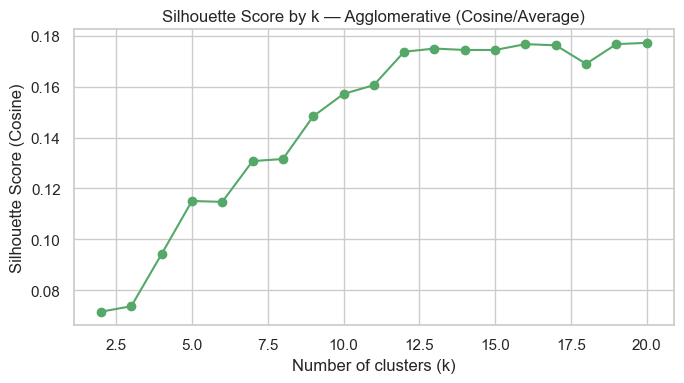

Unconstrained best k: 20 (silhouette = 0.1772)
Chosen k (k >= 4): 20 (silhouette = 0.1772)

Cluster sizes (Agglomerative Cosine):
cluster
0     269
1     839
2      86
3      17
4      55
5     346
6     277
7      39
8     247
9     447
10    307
11     10
12     16
13      2
14     86
15     28
16      1
17    139
18     70
19     91
Name: count, dtype: int64

Per-cluster duration statistics (Agglomerative Cosine):


,count,mean,std,min,max
cluster,,,,,
0,269,57.127568,21.381843,1.140000,85.048333
1,839,40.155443,14.891584,0.355555,80.203888
2,86,58.201353,26.804678,0.693333,84.638611
3,17,43.646797,16.803885,0.559166,63.093888
4,55,36.199429,13.623847,1.523888,63.124444
5,346,34.903920,11.514970,0.471388,78.493333
6,277,2.074107,6.847522,0.350000,81.357222
7,39,44.360982,15.755217,1.717222,64.726666
8,247,50.045253,19.370428,0.854444,81.969722


In [23]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import pairwise_distances, silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# 1. Compute pairwise Cosine distance matrix 
# (Since Agglomerative expects a dense matrix for precomputed metrics, we precompute it)
cosine_distance_matrix = pairwise_distances(X_scaled, metric="cosine")

# 2. Iterate to find good K via silhouette score (using cosine metric for silhouette as well)
k_range_agg = range(2, 21)
silhouette_scores_agg = []

# Use average linkage. Complete linkage is also an option but average tends to be more robust with Cosine.
for k in k_range_agg:
    agg = AgglomerativeClustering(n_clusters=k, metric="precomputed", linkage="average")
    labels = agg.fit_predict(cosine_distance_matrix)
    score = silhouette_score(cosine_distance_matrix, labels, metric="precomputed")
    silhouette_scores_agg.append(score)

plt.figure(figsize=(7, 4))
plt.plot(list(k_range_agg), silhouette_scores_agg, marker="o", color="C2")
plt.title("Silhouette Score by k — Agglomerative (Cosine/Average)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score (Cosine)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Enforce MIN_USEFUL_K=4 to avoid trivial 2-cluster domination if present
MIN_USEFUL_K = 4
eligible_k_agg = [k for k in k_range_agg if k >= MIN_USEFUL_K]
eligible_scores_agg = [silhouette_scores_agg[i] for i, k in enumerate(k_range_agg) if k >= MIN_USEFUL_K]
optimal_k_agg = eligible_k_agg[int(np.argmax(eligible_scores_agg))]

print(f"Unconstrained best k: {list(k_range_agg)[int(np.argmax(silhouette_scores_agg))]} (silhouette = {max(silhouette_scores_agg):.4f})")
print(f"Chosen k (k >= {MIN_USEFUL_K}): {optimal_k_agg} (silhouette = {max(eligible_scores_agg):.4f})")

# Fit final model
final_agg = AgglomerativeClustering(n_clusters=optimal_k_agg, metric="precomputed", linkage="average")
cluster_labels_agg = final_agg.fit_predict(cosine_distance_matrix)

df_clustered_agg = df_filtered.reset_index(drop=True).copy()
df_clustered_agg["cluster"] = cluster_labels_agg

print("\nCluster sizes (Agglomerative Cosine):")
print(df_clustered_agg["cluster"].value_counts().sort_index())

cluster_duration_stats_agg = df_clustered_agg.groupby("cluster")["durationInHours"].agg(
    ["count", "mean", "std", "min", "max"]
)
print("\nPer-cluster duration statistics (Agglomerative Cosine):")
display(cluster_duration_stats_agg)

## 9. Alternative Approach 4: UMAP + HDBSCAN

**UMAP** performs non-linear dimensionality reduction, capturing the topology of the highly sparse space much better than PCA (which only finds orthogonal linear components).
**HDBSCAN** then clusters that projection using density rather than distance from a center, easily handling arbitrary shapes and correctly identifying noisy outliers (assigning them a label of `-1`).

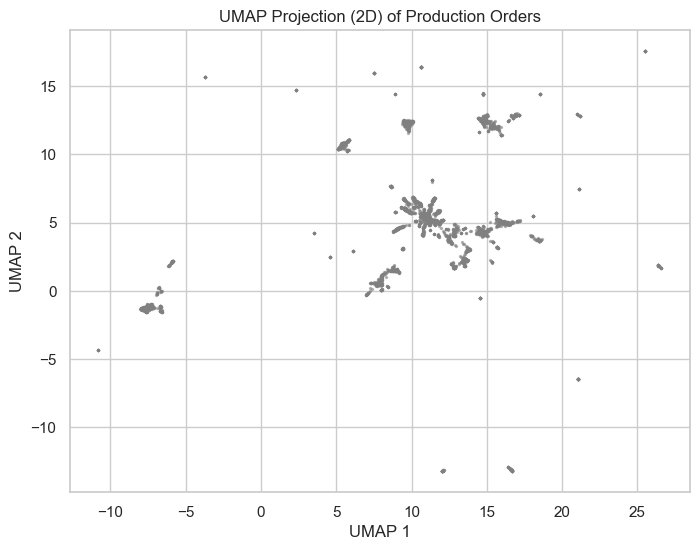


Cluster sizes (UMAP + HDBSCAN | -1 = Outliers):
cluster
-1     549
 0      28
 1      28
 2      52
 3      55
 4      31
 5      30
 6     161
 7      37
 8      21
 9      26
 10     20
 11    191
 12     24
 13     21
 14     74
 15     55
 16     22
 17     31
 18     26
 19     98
 20     35
 21     91
 22     51
 23     40
 24     99
 25    134
 26    107
 27     22
 28     48
 29     36
 30     20
 31     86
 32     70
 33     42
 34     22
 35     25
 36     57
 37     64
 38     37
 39     48
 40     41
 41     61
 42     46
 43     57
 44     24
 45     30
 46     57
 47     87
 48     54
 49     22
 50    179
Name: count, dtype: int64


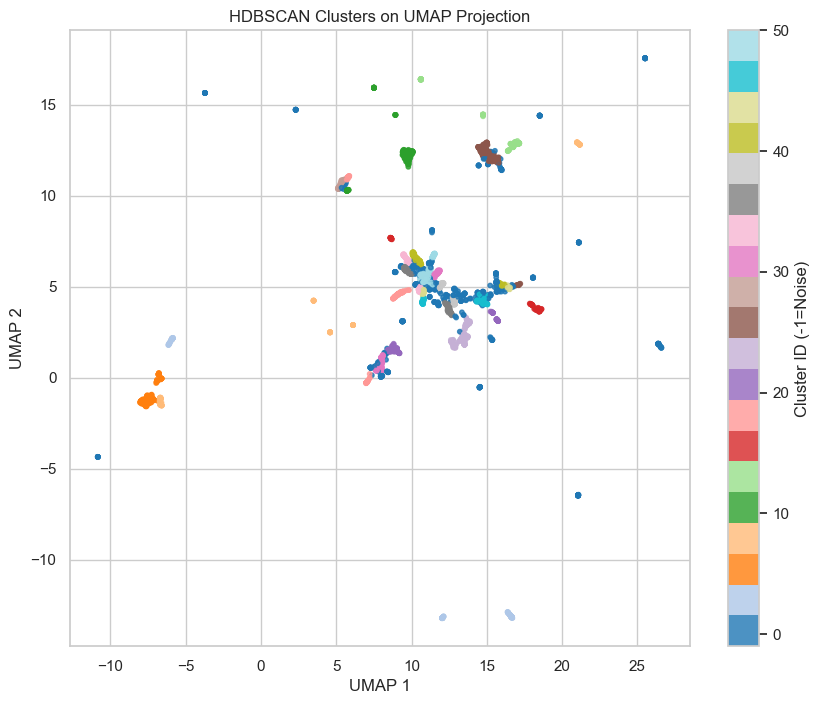


Per-cluster duration statistics (UMAP + HDBSCAN):


,count,mean,std,min,max
cluster,,,,,
-1,549,39.833258,21.523404,0.422777,84.623611
0,28,40.843095,15.326090,1.314444,70.986388
1,28,37.989553,2.614310,31.860833,42.698333
2,52,55.752804,11.744633,12.951944,78.941111
3,55,50.770106,8.776759,17.718888,64.421388
4,31,48.344534,16.179171,2.464444,63.728055
5,30,34.382203,23.015687,0.854444,64.668888
6,161,51.923602,18.410487,0.980555,81.969722
7,37,3.122327,8.882428,0.431388,54.888055


In [24]:
import umap
from sklearn.cluster import HDBSCAN

# 1. Non-linear dimensionality reduction with UMAP
# We reduce down to 2 or 3 components primarily for density clustering and visualization.
# For binary/scaled data, metric="cosine" or "euclidean" can be used. We stick to Euclidean here first 
# as StandardScaler output is centered and HDBSCAN handles Euclidean density natively.
reducer = umap.UMAP(n_neighbors=30, min_dist=0.0, n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], s=2, alpha=0.5, c="gray")
plt.title("UMAP Projection (2D) of Production Orders")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.grid(True)
plt.show()

# 2. Density-based clustering with HDBSCAN
# min_cluster_size dictates the smallest allowable group. Let's say 20 orders minimum to form a cluster.
hdbscan_model = HDBSCAN(min_cluster_size=20, min_samples=5)
cluster_labels_hdbscan = hdbscan_model.fit_predict(X_umap)

df_clustered_umap = df_filtered.reset_index(drop=True).copy()
df_clustered_umap["cluster"] = cluster_labels_hdbscan

print("\nCluster sizes (UMAP + HDBSCAN | -1 = Outliers):")
print(df_clustered_umap["cluster"].value_counts().sort_index())

# Visualize clusters
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_umap[:, 0], X_umap[:, 1], 
    c=cluster_labels_hdbscan, 
    cmap="tab20", 
    s=10, 
    alpha=0.8
)
plt.title("HDBSCAN Clusters on UMAP Projection")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(scatter, label="Cluster ID (-1=Noise)")
plt.show()

cluster_duration_stats_hdbscan = df_clustered_umap.groupby("cluster")["durationInHours"].agg(
    ["count", "mean", "std", "min", "max"]
)
print("\nPer-cluster duration statistics (UMAP + HDBSCAN):")
display(cluster_duration_stats_hdbscan)

## 10. Evaluate Alternative Models against Business Similarity Sets

We reuse the `validation_df` and output logic from earlier to see if our new alternative algorithms successfully grouped the business sets.